# Exercise - 01

Given a CSV file that includes the score of students in math and cs subjects, your job is to find the correlation between the Math and CS scores.

Dataset: [inputs.csv](inputs.csv)

## Load input data

In [24]:
import pandas as pd
import numpy as np

# Load the CSV file
df = pd.read_csv('inputs.csv')

#View the first 5 rows of data
df.head()

,name,math,cs
0,david,92,98
1,laura,56,68
2,sanjay,88,81
3,wei,70,80
4,jeff,80,83


## Visualize the data

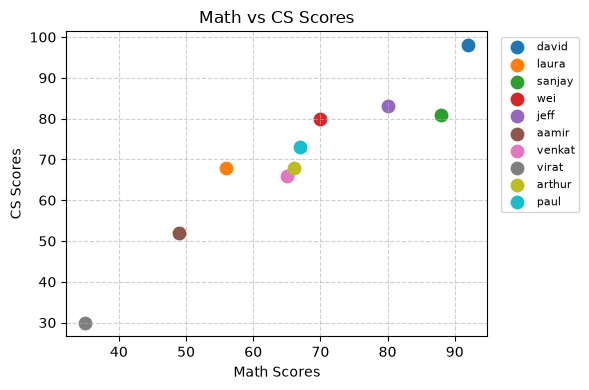

In [17]:
from matplotlib import pyplot as plt

%matplotlib inline
def plot_data(df):
    plt.figure(figsize=(6, 4))
    for _, row in df.iterrows():
        plt.scatter(row['math'], row['cs'], s=80, label=row['name'])
    plt.xlabel('Math Scores')
    plt.ylabel('CS Scores')
    plt.title('Math vs CS Scores')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

plot_data(df)

## Lets implement Gradient descent algorithum to find prediction function

$$\frac{d}{dm} = \frac{2}{n} \sum_{i=1}^{n} - x_i (y_i - (mx_i + b))$$

$$\frac{d}{db} = \frac{2}{n} \sum_{i=1}^{n} - (y_i - (mx_i + b))$$


In [ ]:
def gradient_descent(x, y, learning_rate = 0.0002, iterations = 1000000):
    m = 0
    b = 0
    n = len(x)
    for i in range(iterations):
        y_pred = m * x + b # Predicted values
        error = y - y_pred

        cost = (1/n) * np.sum(error ** 2) # MSE

        m_gradient =  - (2/n) * np.sum(x * error)
        b_gradient = - (2/n) * np.sum(error)


        m -= learning_rate * m_gradient
        b -= learning_rate * b_gradient
        print(f"Iteration {i}: m = {m:.4f}, b = {b:.4f}, cost = {cost:.4f}")

    return round(m, 2), round(b, 2)

m, b = gradient_descent(df["math"], df["cs"])

print(f"Optimal slope (m): {m}")
print(f"Optimal intercept (b): {b}")

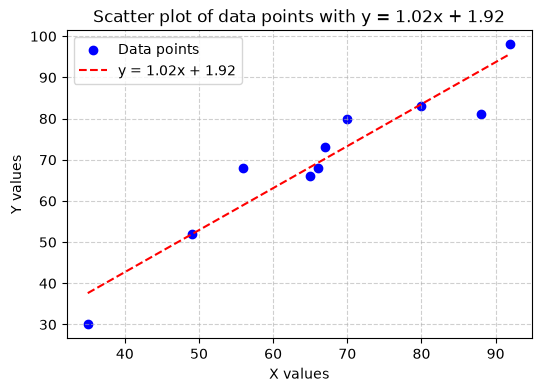

In [ ]:
'''

Iteration 999999: m = 1.0177, b = 1.9152, cost = 31.6045
Optimal slope (m): 1.02
Optimal intercept (b): 1.92

'''


%matplotlib inline

def plot_prediction_function(x, y):
    plt.figure(figsize=(6, 4))
    plt.scatter(x, y, color='blue', label='Data points')
    x_line = np.linspace(min(x), max(x), 100)
    plt.plot(x_line, m * x_line + b, color='red', linestyle='--', label=f'y = {m}x + {b}')
    plt.xlabel('X values')
    plt.ylabel('Y values')
    plt.title(f'Scatter plot of data points with y = {m}x + {b}')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

plot_prediction_function(df["math"], df["cs"])